<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/DA/EDA_Benh_Dai_Thao_Duong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Phân tích khám phá về bệnh đái tháo đường**

##**1.Định nghĩa vấn đề**
+ **Mô tả**:
   + Bộ dữ liệu gồm 768 mẫu từ bệnh nhân đều là nữ giới, ít nhất 21 tuổi, và có nguồn gốc người da đỏ Pima, sống gần Phoenix, Arizona.
   + 8 đặc điểm được đo từ mỗi mẫu + 1 biến phân loại (có/không mắc tiểu đường)
+ **Dữ liệu vào**:
   + Số lần mang thai (lần)
   + Nồng độ glucose huyết tương sau 2 giờ trong xét nghiệm dung nạp glucose đường uống (mg/dL)
   + Huyết áp tâm trương (mm Hg)
   + Độ dày nếp gấp da cơ tam đầu (mm)
   + Nồng độ insulin huyết thanh sau 2 giờ (mu U/ml)
   + Chỉ số khối cơ thể BMI (kg/m²)
   + Hàm phả hệ tiểu đường ()
   + Tuổi (năm)
   + Biến phân loại (nhị phân)
+ **Dữ liệu ra**:
   + Dự đoán bệnh nhân có tiểu đường không (Biến phân loại 0 hoặc 1)
+ **Mục tiêu**:
   + Phân tích bộ dữ liệu bệnh đái tháo đường nhằm hiểu rõ các yếu tố liên quan đến nguy cơ mắc bệnh.
   + Vận dụng kiến thức về dinh dưỡng để đánh giá ảnh hưởng của chế độ ăn uống đến tình trạng bệnh.


## **2.Chuẩn bị vấn đề**

### **2.1.Khai báo thư viện**

In [ ]:
# Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.model_selection as mod
import sklearn.neighbors as nei
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import LeaveOneOut
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report, precision_recall_curve, average_precision_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import operator
%matplotlib inline

### **2.2.Nạp dữ liệu**

In [ ]:
#load data
pima = pd.read_csv('https://raw.githubusercontent.com/mihhwiNick/DA_project/refs/heads/main/pima-indians-diabetes.data.csv')

### **2.3.Kiểm tra và làm sạch dữ liệu**

#### **2.3.1. Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [ ]:
# Loại bỏ cột Outcome khi kiểm tra giá trị 0
cols_to_check = pima.columns.drop("Outcome")
rows_with_zero = (pima[cols_to_check] == 0).any(axis=1)
count_rows_with_zero = rows_with_zero.sum()

has_null = pima.isnull().sum().any()
has_nan  = pima.isna().sum().any()
n_duplicated = pima.duplicated().sum()

print('Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display(pima[pima.isnull().any(axis=1)])

print(f'+ Có giá trị NaN: {has_nan}')
if has_nan:
    display(pima[pima.isna().any(axis=1)])

print(f'+ Số dòng trùng: {n_duplicated}')
if n_duplicated > 0:
    s_query1 = "`Pregnancies`==6 and `Glucose`==148 and `Outcome`==1"
    s_query2 = "`Pregnancies`==1 and `Glucose`==85 and `Outcome`==0"
    display(pima.query(s_query1))
    display(pima.query(s_query2))
    display(pima[pima.duplicated()])

zero_counts_all = (pima == 0).sum()


cols_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Đếm số dòng có giá trị = 0 ở các cột này
zero_counts = (pima[cols_check] == 0).sum()

print("Số lượng dòng có giá trị = 0 ở từng cột được chọn:")
print(zero_counts)

Tính toàn vẹn dữ liệu:
+ Có giá trị Null: False
+ Có giá trị NaN: False
+ Số dòng trùng: 0
Số lượng dòng có giá trị = 0 ở từng cột được chọn:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


**Nhận xét**:
+ Không có dữ liệu nào trùng nhau
+ Dữ liệu không có giá trị rỗng (NaN, Null).
+ Tuy nhiên, khi kiểm tra chi tiết, phát hiện một số cột có giá trị = 0 không hợp lý về mặt y học, được coi là dữ liệu thiếu:
  + Glucose: không thể bằng 0 vì cơ thể luôn có đường huyết lưu hành.

  + BloodPressure: không thể bằng 0, vì huyết áp 0 chỉ xảy ra khi đã tử vong.

  + SkinThickness: không thể bằng 0, lớp mỡ dưới da luôn có độ dày nhất định.

  + Insulin: không thể bằng 0, vì tuyến tụy luôn tiết insulin nền.

  + BMI: không thể bằng 0, vì chỉ số khối cơ thể = 0 nghĩa là cân nặng = 0, điều này không thực tế.

## **3.Phân tích khám phá dữ liệu**

### **3.1.Phân tích đơn biến (Univariable Analysis)**

#### **3.1.1. Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [ ]:
# Get shape
print(f'+ Shape: {pima.shape}')

# Get types
print(f'\n+ Data Types:\n{pima.dtypes}')

# Check the first 5 rows (head)
print('\n+ First 5 rows:')
display(pima.head(5))

# Check the last 5 rows (tail)
print('\n+ Last 5 rows:')
display(pima.tail(5))

# info
print('\n + Basic Information: ')
pima.info()

+ Shape: (768, 9)

+ Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

+ First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1



+ Last 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180.0,32.9,0.171,63,0
764,2,122,70,27,30.5,36.8,0.340,27,0
765,5,121,72,23,112.0,26.2,0.245,30,0
766,1,126,60,23,30.5,30.1,0.349,47,1
767,1,93,70,31,30.5,30.4,0.315,23,0



 + Basic Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 54.1 KB


**Nhận xét**:
+ Dữ liệu có 8 tính chất để phân lớp: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
+ Các giá trị đều là số học, thuộc kiểu int64 và float64
+ Tổng số dòng dữ liệu là 768 dòng
+ Dữ liệu phân lớp nằm ở cột Outcome, gồm 2 giá trị: 0 (không mắc bệnh) và 1 (mắc bệnh)


#### **3.1.2. Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [ ]:
description = pima.drop(columns=["Outcome"]).describe().T
display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,27.334635,9.229014,7.000,23.00000,23.0000,32.00000,99.00
Insulin,768.0,94.652344,105.547598,14.000,30.50000,31.2500,127.25000,846.00
BMI,768.0,32.450911,6.875366,18.200,27.50000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


**Nhận xét**:
+ **Pregnancies:** Trung bình 3.84, dao động 0–17 → hợp lý, vì có thể có phụ nữ chưa mang thai.
+ **Glucose:** Giá trị trung bình là 120.89, với mức cao nhất là 199. Phân phối cho thấy có sự đa dạng về mức đường huyết trong nhóm nghiên cứu, phản ánh rõ nguy cơ tiểu đường.
+ **BloodPressure:** Huyết áp trung bình là 69.1, nằm trong ngưỡng bình thường. Giá trị cao nhất là 122, cho thấy có một số trường hợp tăng huyết áp.
+ **SkinThickness:** Độ dày lớp mỡ dưới da trung bình là 20.5, với giá trị cao nhất là 99. Phân phối khá rộng, thể hiện sự khác biệt về thể trạng giữa các cá nhân.
+ **Insulin:** Mức insulin trung bình là 79.8, nhưng giá trị cao nhất lên tới 846, cho thấy có một số trường hợp rối loạn chuyển hóa rõ rệt.
+ **BMI:** Chỉ số khối cơ thể trung bình là 31.99, nằm trong ngưỡng thừa cân. Một số cá nhân có BMI rất cao (tối đa 67.1), cho thấy nguy cơ béo phì.
+ **DiabetesPedigreeFunction:** Hệ số di truyền trung bình là 0.47, dao động từ 0.078 đến 2.42. Phân phối này phản ánh mức độ ảnh hưởng của yếu tố di truyền đến nguy cơ mắc bệnh.
+ **Age:** Tuổi trung bình là 33.24, dao động từ 21 đến 81. Phân phối tuổi phù hợp với nhóm dân số trưởng thành, có nguy cơ tiểu đường tăng theo tuổi.


#### **3.1.3. Tần số xuất hiện trên dữ liệu phân loại**

In [ ]:
pima["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


**Nhận xét**:
+ Dữ liệu không cân bằng: lớp 0 chiếm khoảng 65%, lớp 1 chiếm khoảng 35%, điều này có thể làm mô hình thiên lệch về lớp đa số.
+ **Giải pháp**: có thể áp dụng oversampling (SMOTE) để tăng số mẫu lớp 1, hoặc undersampling để giảm số mẫu lớp 0

#### **3.1.4.Biểu đồ violin cho từng biến**

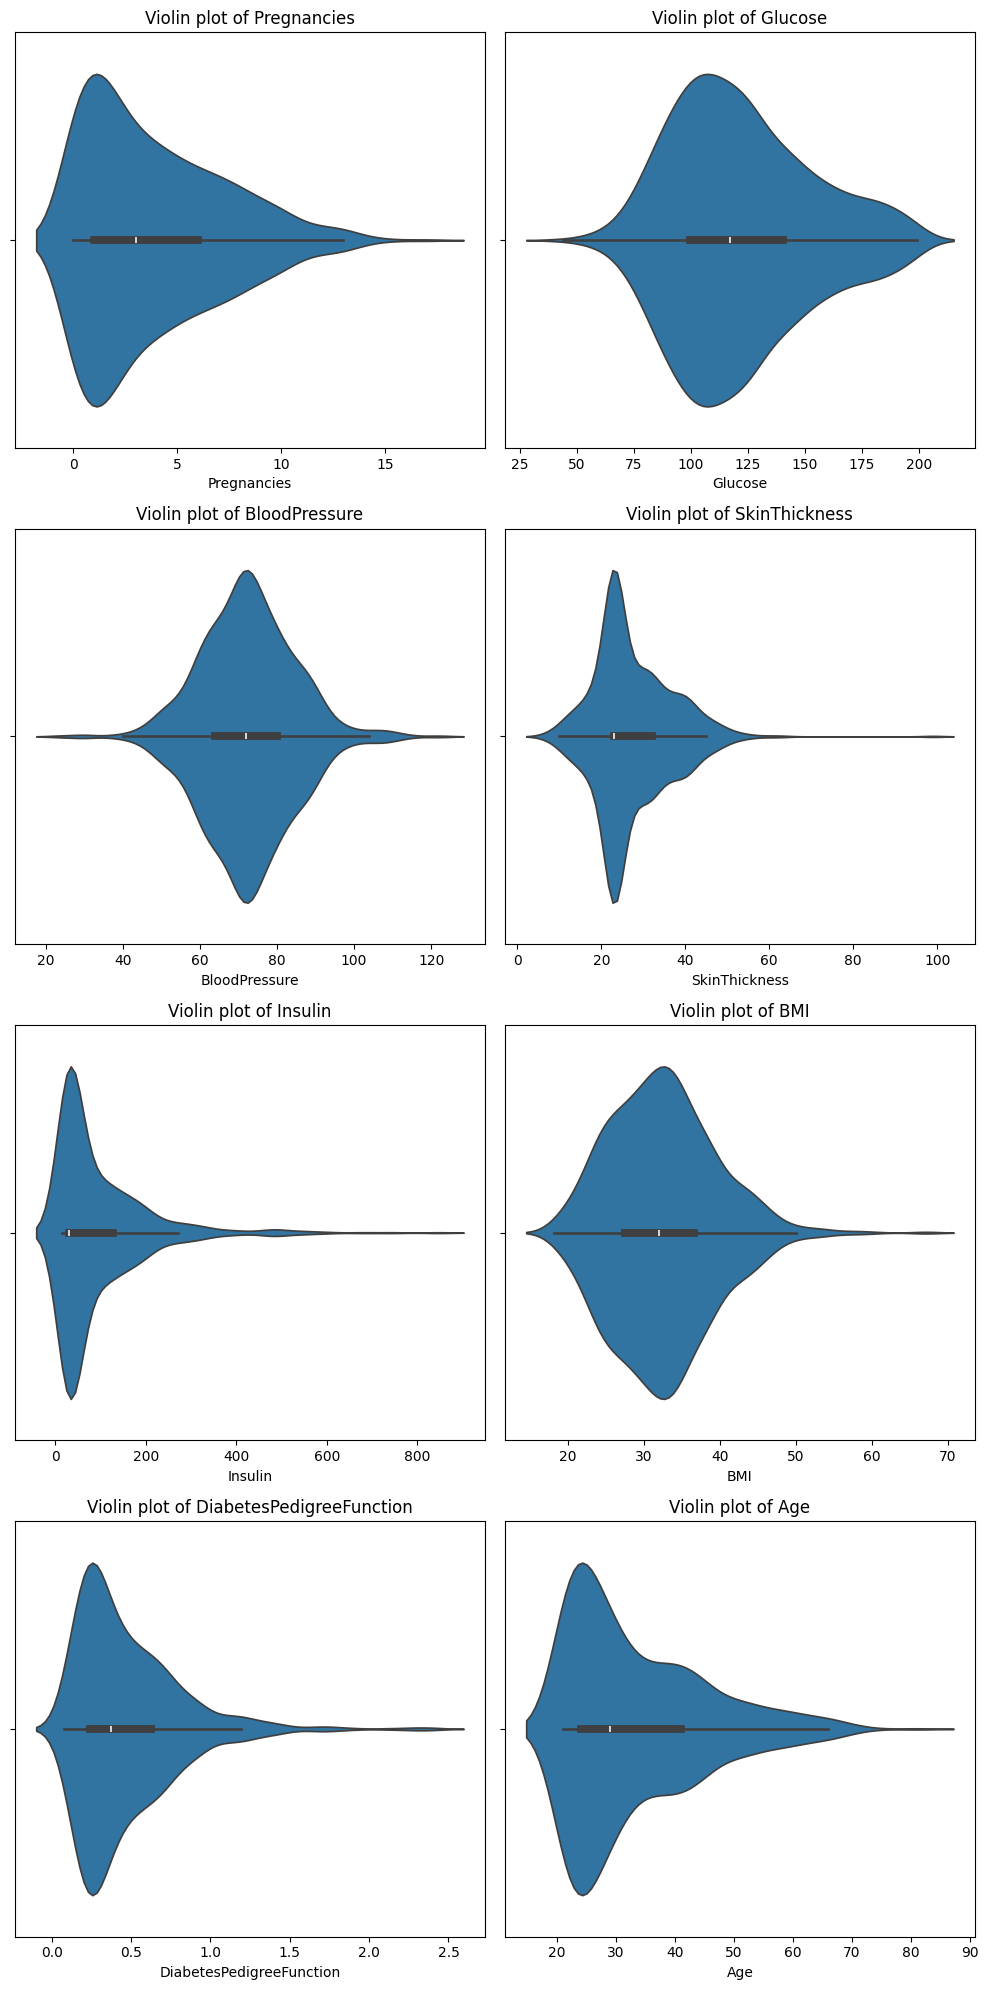

In [ ]:
num_columns = len(pima.columns.drop('Outcome'))
num_rows = (num_columns + 1) // 2

plt.figure(figsize=(10, 5*num_rows))
for i, column in enumerate(pima.columns.drop('Outcome')):
    plt.subplot(num_rows, 2, i+1)
    sns.violinplot(x=pima[column])
    plt.title(f'Violin plot of {column}')

plt.tight_layout()
plt.show()

#### **3.1.5.Biểu đồ ước lượng mật độ kernel (KDE) cho từng biến**

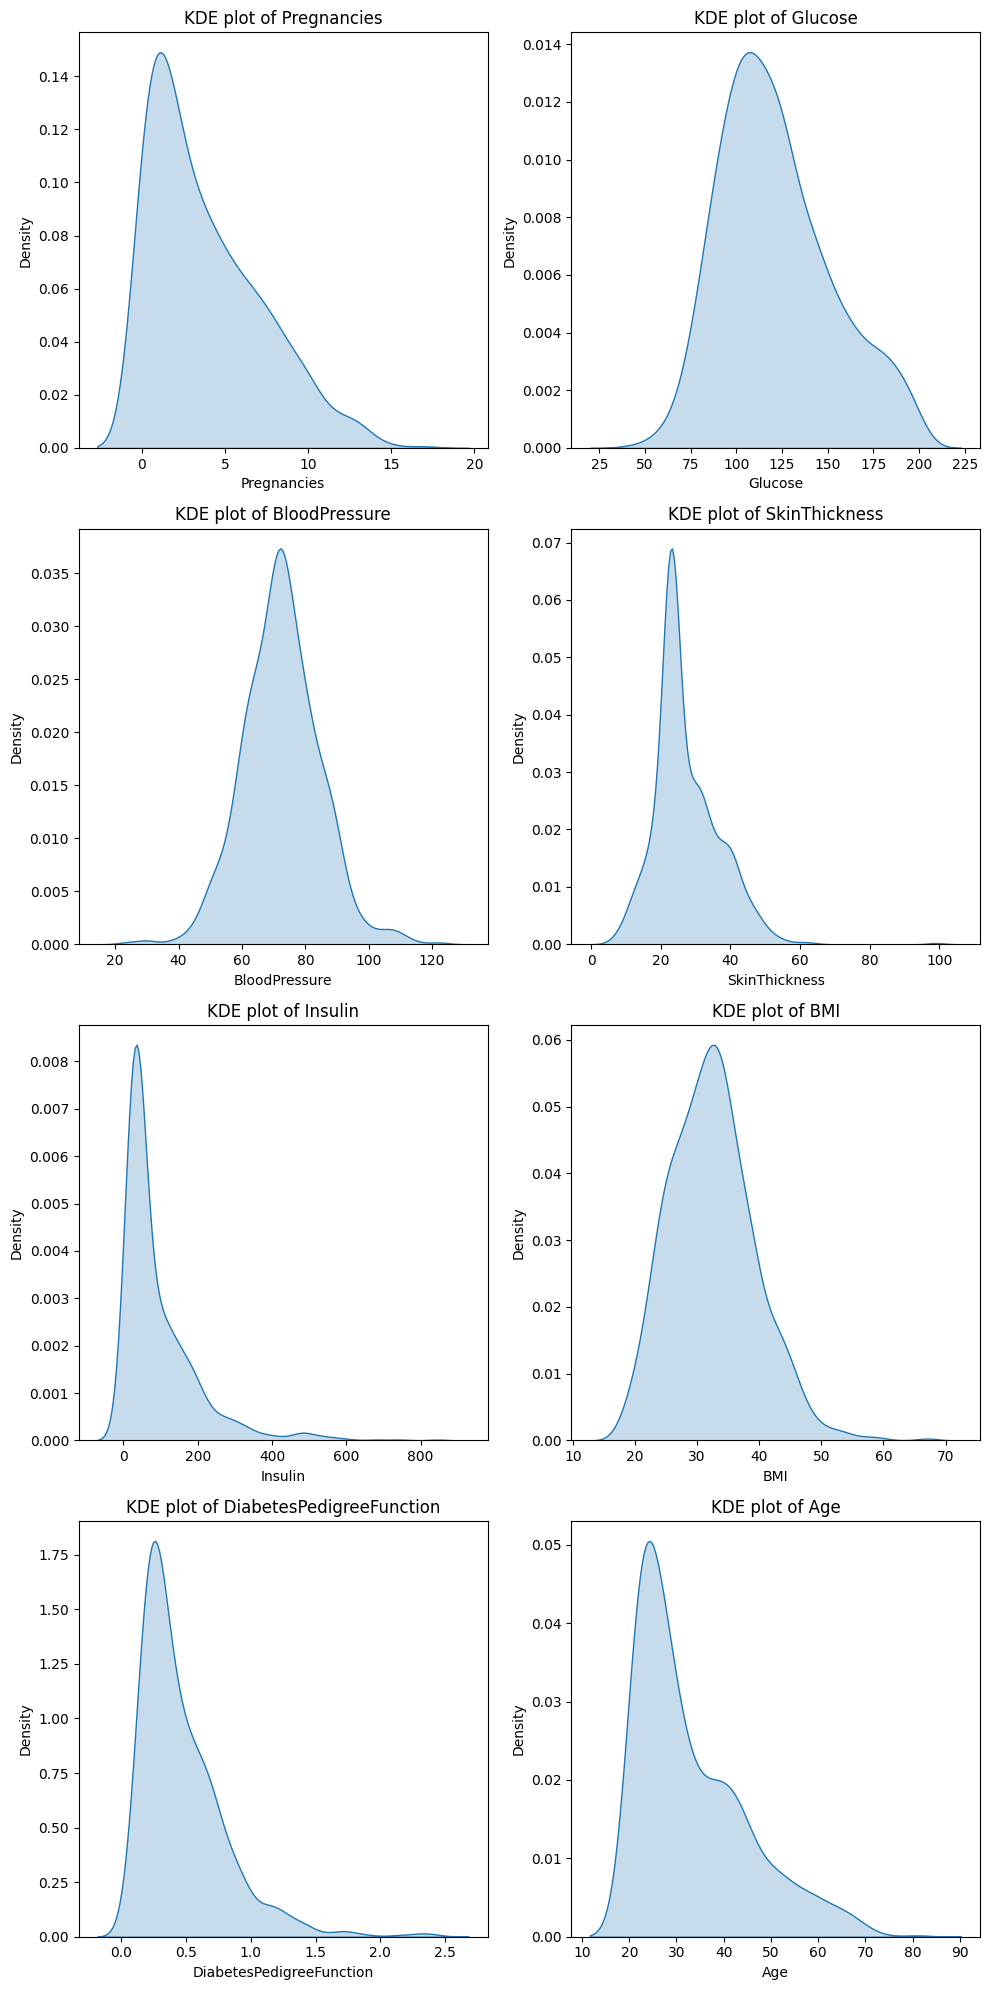

In [ ]:
num_columns = len(pima.columns.drop('Outcome'))
num_rows = (num_columns + 1) // 2

plt.figure(figsize=(10, 5*num_rows))

# Select only numeric columns for KDE plot
numeric_cols = pima.select_dtypes(include=np.number).columns.drop('Outcome', errors='ignore')

for i, column in enumerate(numeric_cols):
    plt.subplot(num_rows, 2, i+1)
    sns.kdeplot(data=pima[column], fill=True)
    plt.title(f'KDE plot of {column}')

plt.tight_layout()
plt.show()

### **3.3.Phân tích đa biến (Multivariable Analysis)**

#### **3.2.1. So sánh trung bình các đặc điểm theo nhóm Outcome**

In [ ]:
# Tính giá trị trung bình của các biến theo nhóm Outcome
pima.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,26.058000,83.188000,30.880200,0.429734,31.190000
1,4.865672,142.130597,75.123134,29.716418,116.041045,35.381343,0.550500,37.067164


**Nhận xét**: Kết quả cho thấy nhóm phụ nữ mắc tiểu đường có xu hướng sở hữu các đặc điểm sinh lý với giá trị trung bình cao hơn so với nhóm không mắc bệnh.

In [ ]:
# Lấy giá trị trung bình của từng biến trong dataset
pima.mean()

,0
Pregnancies,3.845052
Glucose,121.656250
BloodPressure,72.386719
SkinThickness,27.334635
Insulin,94.652344
BMI,32.450911
DiabetesPedigreeFunction,0.471876
Age,33.240885
Outcome,0.348958


**Nhận xét**:
- **Pregnancies:** Trung bình 3.85 lần mang thai, phản ánh nhóm phụ nữ đã từng sinh nở, phù hợp với đối tượng nghiên cứu.
- **Glucose:** Mức đường huyết trung bình là 121.66 mg/dL, tiệm cận ngưỡng chẩn đoán tiểu đường (126 mg/dL), cho thấy nguy cơ bệnh trong tập dữ liệu là đáng chú ý.
- **BloodPressure:** Huyết áp trung bình là 72.39 mmHg, nằm trong ngưỡng bình thường. Đây là mức ổn định, tuy nhiên vẫn cần kiểm tra sự khác biệt giữa các nhóm bệnh.
- **SkinThickness:** Độ dày lớp mỡ dưới da trung bình là 27.33 mm, cho thấy thể trạng tương đối ổn định trong nhóm nghiên cứu. Đây là một đặc điểm có thể liên quan đến tình trạng béo phì và nguy cơ rối loạn chuyển hóa.
- **Insulin:** Mức insulin trung bình là 94.65 µU/mL, cho thấy chức năng chuyển hóa ở mức phổ thông. Tuy nhiên, đây vẫn là biến cần theo dõi vì có thể liên quan đến tình trạng kháng insulin.
- **BMI:** Chỉ số khối cơ thể trung bình là 32.45, vượt ngưỡng 30 – cho thấy tình trạng thừa cân hoặc béo phì là phổ biến trong tập dữ liệu.
- **DiabetesPedigreeFunction:** Hệ số di truyền trung bình là 0.47, cho thấy mức độ ảnh hưởng di truyền ở mức vừa phải.
- **Age:** Tuổi trung bình là 33.24, phù hợp với nhóm dân số trưởng thành, độ tuổi có nguy cơ tiểu đường bắt đầu tăng.
- **Outcome:** Tỷ lệ trung bình là 0.34, tức khoảng 35% người trong tập dữ liệu có kết quả dương tính với tiểu đường — đủ để phân tích sự khác biệt giữa hai nhóm.


#### **3.2.2. Phân tích tương quan**

In [ ]:
pima.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.032568,-0.055697,0.021546,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.172143,0.357573,0.231400,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.147809,-0.028721,0.281132,-0.002378,0.324915,0.165723
SkinThickness,0.032568,0.172143,0.147809,1.000000,0.238188,0.546951,0.142977,0.054514,0.189065
Insulin,-0.055697,0.357573,-0.028721,0.238188,1.000000,0.189022,0.178029,-0.015413,0.148457
BMI,0.021546,0.231400,0.281132,0.546951,0.189022,1.000000,0.153506,0.025744,0.312249
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.142977,0.178029,0.153506,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.054514,-0.015413,0.025744,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.189065,0.148457,0.312249,0.173844,0.238356,1.000000


#### **3.2.3.Biểu đồ Pairplot cho tất cả các biến**

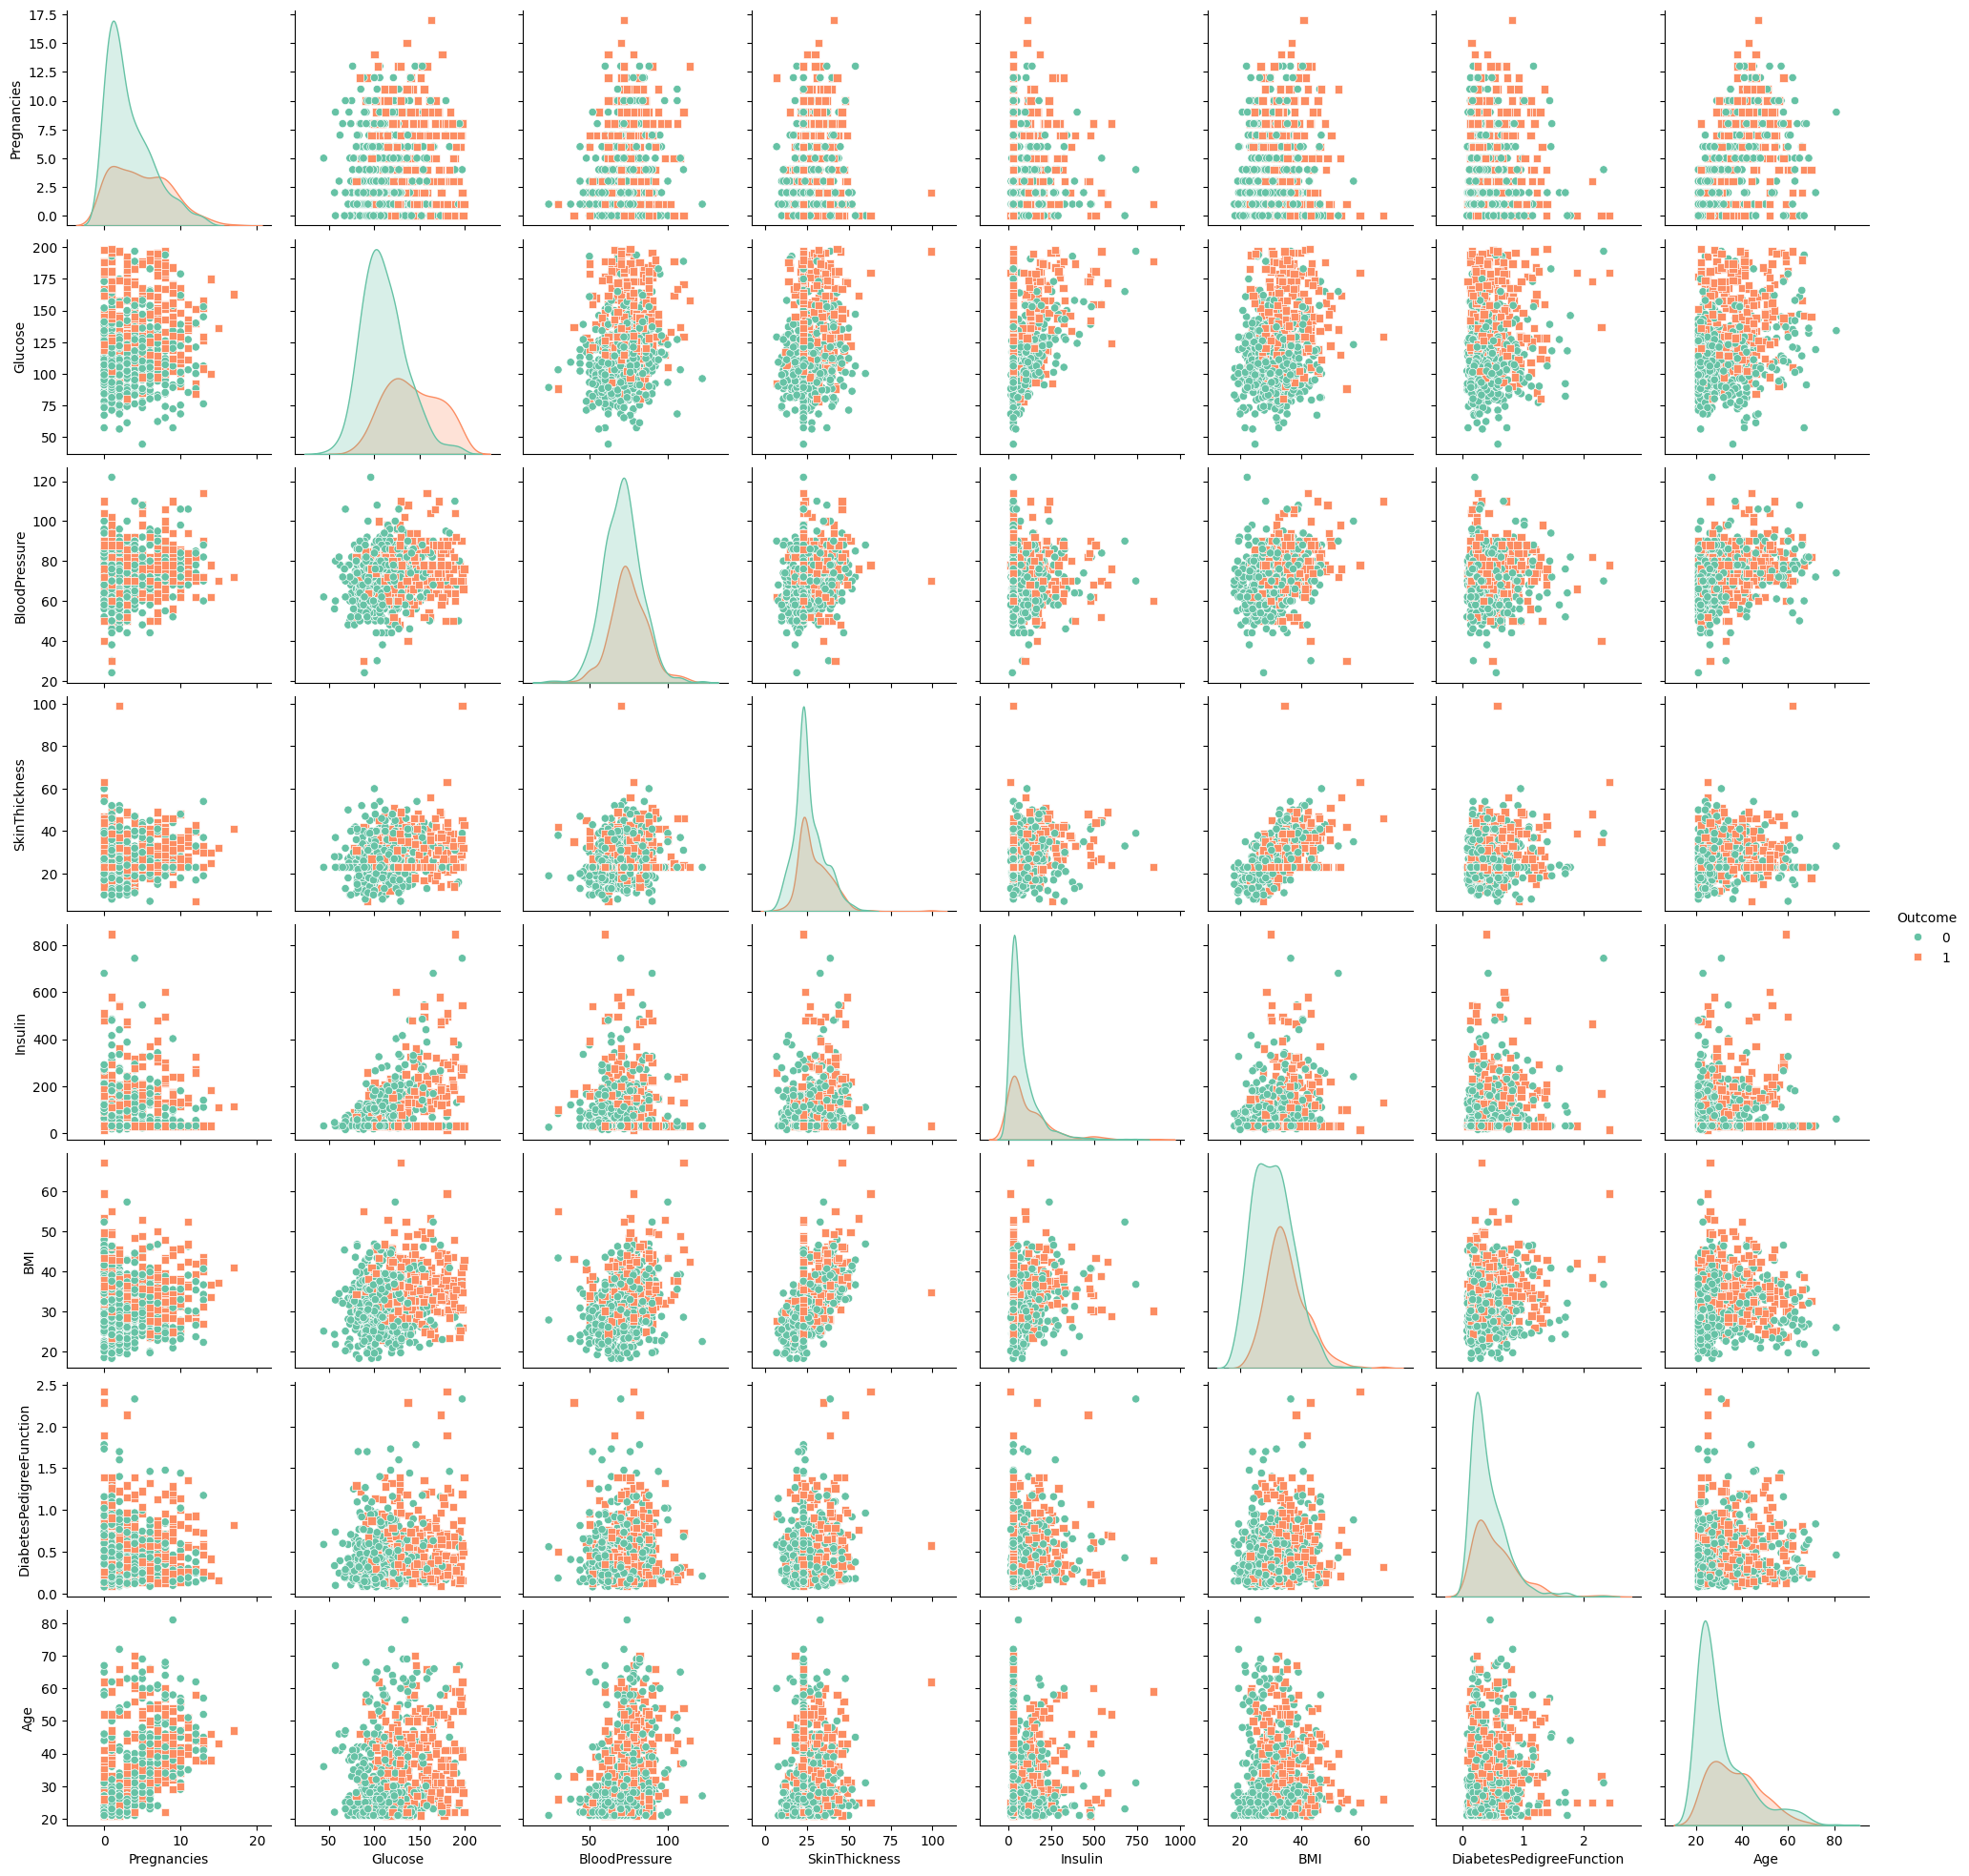

In [ ]:
sns.pairplot(pima, hue='Outcome', markers=["o", "s"], palette="Set2")
plt.show()